<a href="https://colab.research.google.com/github/devikarajeev770-afk/AI-ML-Course/blob/main/DT_Minst.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MNIST classification using RF

In [ ]:
#loading necessary libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
%matplotlib inline
# loading dataset from sklern.datasets
mnist = load_digits()

In [ ]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
pd.DataFrame(mnist.data).head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [ ]:
pd.DataFrame(mnist.target).head()

,0
0,0
1,1
2,2
3,3
4,4


In [ ]:
# display image dimension
np.shape(mnist.images[1])

(8, 8)

In [ ]:
#showing the pixel values in the first image
mnist.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

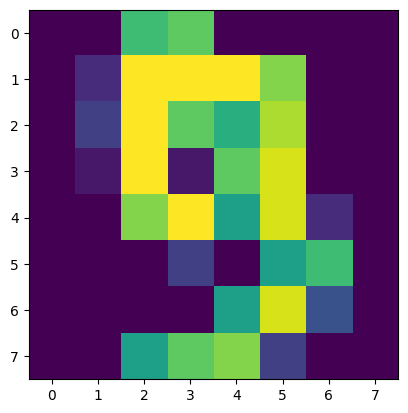

In [ ]:
# displaying the two dimensional array as an image
plt.imshow(mnist.images[9]);

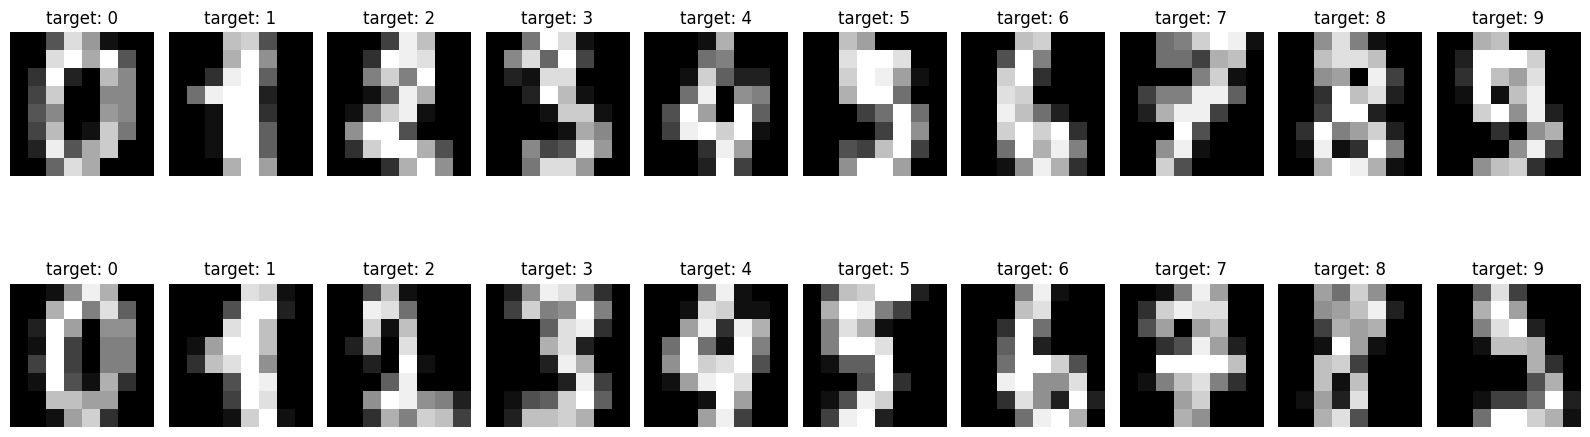

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(16, 6))
for i in range(20):
    axes[i//10, i %10].imshow(mnist.images[i], cmap='gray');
    axes[i//10, i %10].axis('off')
    axes[i//10, i %10].set_title(f"target: {mnist.target[i]}")

plt.tight_layout()

#Machine learning part

In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(mnist.data, mnist.target,train_size=0.55, test_size=0.45,random_state=43)

In [ ]:
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from sklearn.preprocessing import StandardScaler
#Applying Standard scaling to get optimized result
sc = StandardScaler()

In [ ]:
#Applying Standard scaling to get optimized result
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

In [ ]:
# Defining an object for DTC and fitting for the training dataset
dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42 )
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42)

In [ ]:
from sklearn.tree import export_graphviz
import pydot

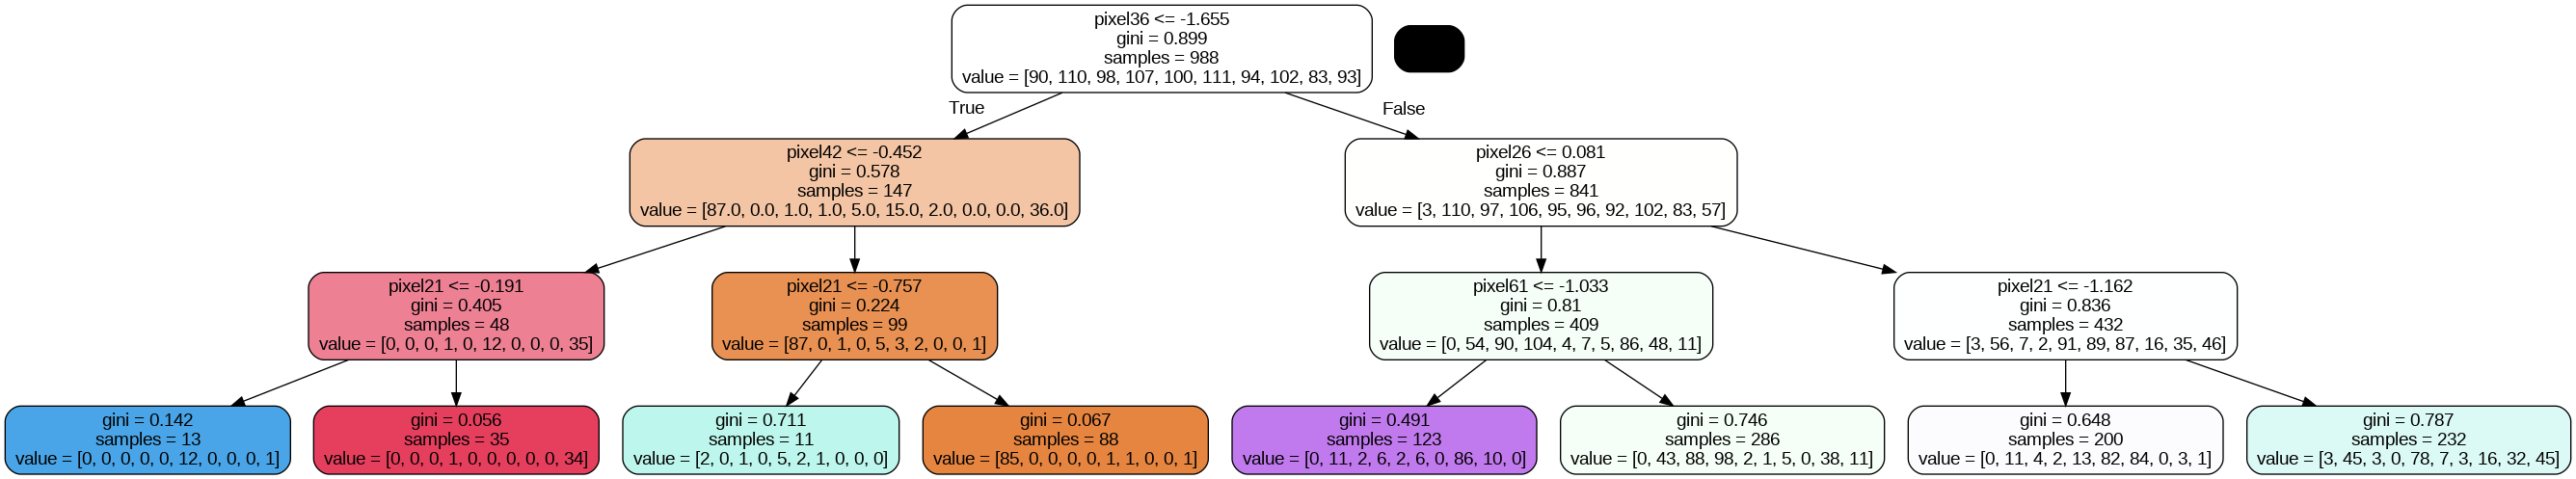

In [ ]:
# Plotting of decision tree
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

# FIX: Create a list of feature names
features = [f"pixel{i}" for i in range(X_train.shape[1])]

# Generate the tree diagram
dot_data = export_graphviz(dt, out_file=None, feature_names=features, filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data)
Image(graph.create_png())

#Implementing ML algorithm

In [ ]:
# Defining an object for DTC and fitting for train dataset
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_train = dt.predict(X_train)
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)

In [ ]:
print('Accuracy of Decision Tree-Train: ', accuracy_score(y_pred_train, y_train))
print('Accuracy of Decision Tree-Test: ', accuracy_score(y_pred, y_test))

Accuracy of Decision Tree-Train:  1.0
Accuracy of Decision Tree-Test:  0.8454882571075402


In [ ]:
#Classification for test before hyperparameter tuning
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        88
           1       0.74      0.81      0.77        72
           2       0.88      0.85      0.86        79
           3       0.86      0.87      0.86        76
           4       0.83      0.72      0.77        81
           5       0.77      0.89      0.82        71
           6       0.87      0.87      0.87        87
           7       0.91      0.92      0.92        77
           8       0.80      0.77      0.78        91
           9       0.85      0.77      0.81        87

    accuracy                           0.85       809
   macro avg       0.84      0.85      0.84       809
weighted avg       0.85      0.85      0.84       809



In [ ]:
# 1. Compute the confusion matrices
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred)
print(cm_train)
print(cm_test)

[[ 90   0   0   0   0   0   0   0   0   0]
 [  0 110   0   0   0   0   0   0   0   0]
 [  0   0  98   0   0   0   0   0   0   0]
 [  0   0   0 107   0   0   0   0   0   0]
 [  0   0   0   0 100   0   0   0   0   0]
 [  0   0   0   0   0 111   0   0   0   0]
 [  0   0   0   0   0   0  94   0   0   0]
 [  0   0   0   0   0   0   0 102   0   0]
 [  0   0   0   0   0   0   0   0  83   0]
 [  0   0   0   0   0   0   0   0   0  93]]
[[88  0  0  0  0  0  0  0  0  0]
 [ 0 58  0  0  2  0  3  1  6  2]
 [ 2  3 67  4  1  0  0  0  1  1]
 [ 0  2  1 66  1  4  0  1  0  1]
 [ 1  8  1  1 58  2  7  1  2  0]
 [ 0  0  0  1  1 63  1  0  1  4]
 [ 1  1  4  0  2  0 76  0  3  0]
 [ 0  1  0  0  1  0  0 71  2  2]
 [ 2  5  3  2  4  3  0  0 70  2]
 [ 0  0  0  3  0 10  0  4  3 67]]


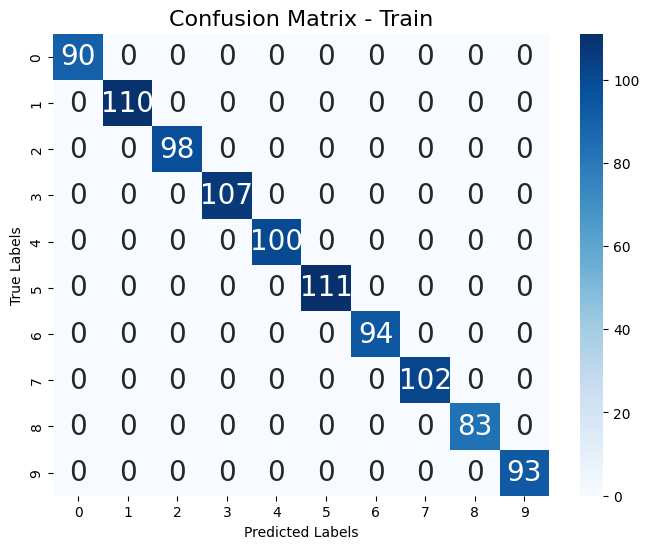

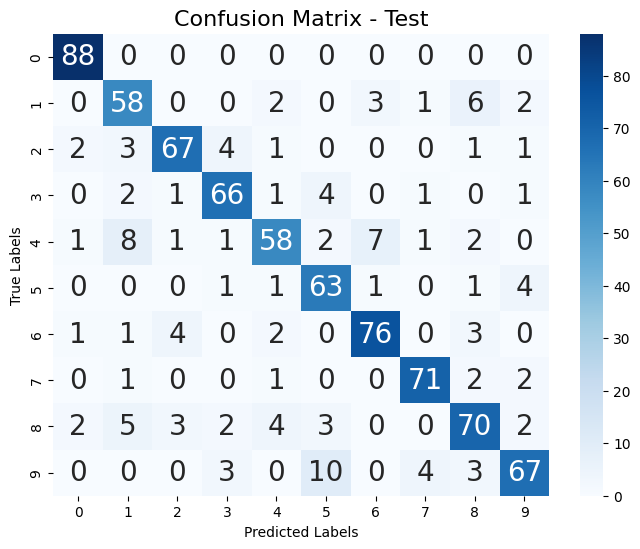

In [ ]:
import seaborn as sns

# 2. Plot Confusion Matrix - Train
plt.figure(figsize=(8, 6))
ax1 = plt.axes()
sns.heatmap(
   cm_train, annot=True,
    annot_kws={"size": 20},
    fmt="d",
    cmap="Blues",
    ax=ax1,
)
ax1.set_title("Confusion Matrix - Train", fontsize=16)
ax1.set_xlabel("Predicted Labels")
ax1.set_ylabel("True Labels")
plt.show()

# 3. Plot Confusion Matrix - Test
plt.figure(figsize=(8, 6))
ax2 = plt.axes()
sns.heatmap(
   cm_test, annot=True, annot_kws={"size": 20}, fmt="d", cmap="Blues", ax=ax2
)
ax2.set_title("Confusion Matrix - Test", fontsize=16)
ax2.set_xlabel("Predicted Labels")
ax2.set_ylabel("True Labels")
plt.show()